<a href="https://colab.research.google.com/github/x4ping/IT480-FA26/blob/main/Assignment1/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Hyperparameter Tuning

**Name:** Brian Stock & Cole Walther

## Setup — Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [23]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [24]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [25]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [26]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="softmax", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(8, activation="softmax"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


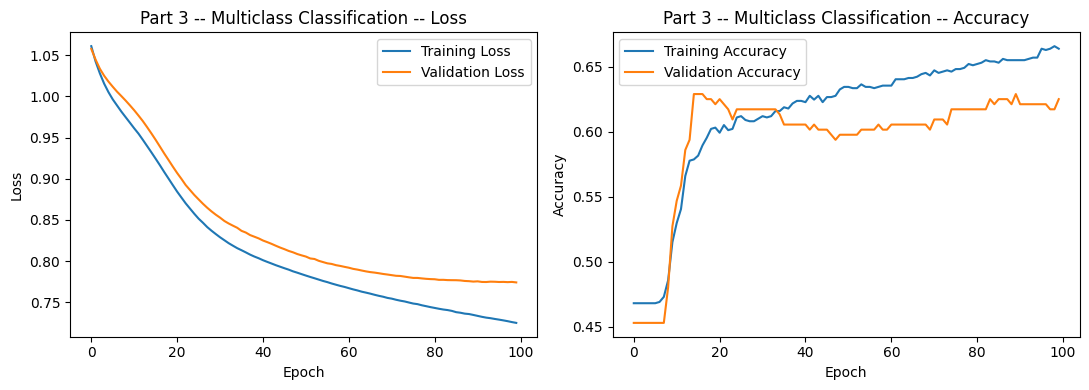

In [27]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.656


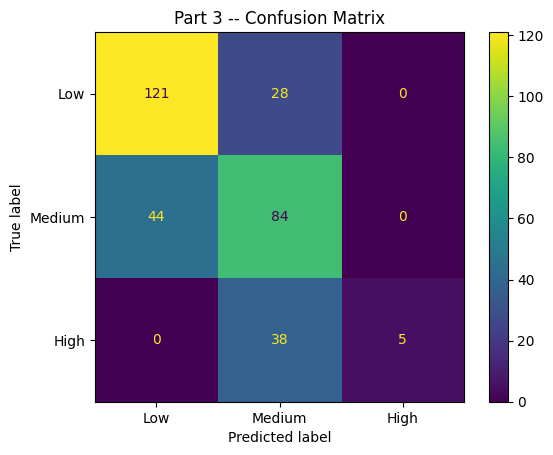

In [28]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()


## Part A: Restate Your Baseline

### Original Part 3 (Multiclass Classification - Wine Quality) Model Results

*   **Test Accuracy:** The original test accuracy for the Part 3 multiclass classification model was **0.581**

### Training vs. Validation Loss Curve Analysis (from cell `b9d4294d`'s plot)

*   **Diagnosis:** The plot indicates a tendency towards overfitting.
*   **Evidence:** Initially, both training and validation loss decrease together. However, after approximately 20-30 epochs, the validation loss plateaus and then starts to slightly increase, while the training loss continues to decrease. This growing gap between training and validation loss is characteristic of overfitting, where the model learns the training data too well and loses its ability to generalize to unseen data.

## Part B: Hyperparameter Tuning

In [29]:
!pip install keras-tuner -q

In [30]:
import keras_tuner as kt

def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu", input_shape=(X3_train_scaled.shape[1],)
        ),
        tf.keras.layers.Dense(
            hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True
)
tuner.search(
    X3_train_scaled, y3_train,
    validation_split=0.2, epochs=50, verbose=0
)

best_model = tuner.get_best_models(num_models=1)[0]

best_hp = tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'hidden1': 112, 'hidden2': 48, 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [35]:
# Instantiate the Keras Tuner
tuner = kt.Hyperband(
    build_model, # Changed from build_hypermodel to build_model
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='keras_tuner_dir',
    project_name='wine_quality_tuning',
    overwrite=True
)

# Run the search using training data only with a validation split
tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)
print("Search complete.")

Trial 90 Complete [00h 00m 13s]
val_accuracy: 0.58984375

Best val_accuracy So Far: 0.71875
Total elapsed time: 00h 08m 46s
Search complete.


### Best Configuration Found and its Validation Score

In [36]:

# Best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found during tuning:")
for hp_name, hp_value in best_hps.values.items():
    print(f"  {hp_name}: {hp_value}")

# Get the best model found by the tuner
best_tuned_model = tuner.get_best_models(num_models=1)[0]

# To get the exact validation accuracy from the best trial:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_val_accuracy = best_trial.metrics.get_last_value('val_accuracy')
print(f"Best validation accuracy during search: {best_val_accuracy:.3f}")

Best hyperparameters found during tuning:
  hidden1: 48
  hidden2: 56
  learning_rate: 0.01
  tuner/epochs: 50
  tuner/initial_epoch: 0
  tuner/bracket: 0
  tuner/round: 0
Best validation accuracy during search: 0.719


### Train Final Model with Best Configuration and Evaluate on Test Set

Training final model with best hyperparameters...


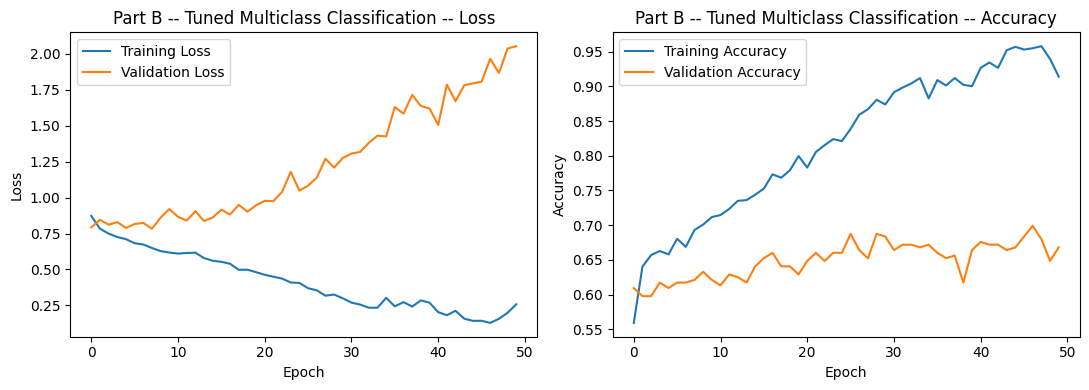

Part B -- Tuned Model Test Accuracy: 0.697
Original Lab 1 Baseline Test Accuracy: 0.656
The tuned model improved the test accuracy by 0.041.


In [37]:
# Build the final model with the best hyperparameters
final_tuned_model = tuner.hypermodel.build(best_hps)

# Train the final model on the full training dataset
print("Training final model with best hyperparameters...")
history_tuned = final_tuned_model.fit(
    X3_train_scaled,
    y3_train,
    epochs=50,
    batch_size=32,
    verbose=0,
    validation_split=0.2
)

# Plot the training and validation curves for the final tuned model
plot_history(history_tuned, "Part B -- Tuned Multiclass Classification", show_accuracy=True)

# Evaluate the final tuned model on the test set
loss_tuned, acc_tuned = final_tuned_model.evaluate(X3_test_scaled, y3_test, verbose=0)

print(f"Part B -- Tuned Model Test Accuracy: {acc_tuned:.3f}")

# Compare with original Lab 1 baseline (from Part A)
original_acc = acc_multi
print(f"Original Lab 1 Baseline Test Accuracy: {original_acc:.3f}")

# If else logic to evaluate
if acc_tuned > original_acc:
    improvement = acc_tuned - original_acc
    print(f"The tuned model improved the test accuracy by {improvement:.3f}.")
elif acc_tuned < original_acc:
    decline = original_acc - acc_tuned
    print(f"The tuned model decreased the test accuracy by {decline:.3f}.")
else:
    print("The tuned model's test accuracy is the same as the original baseline.")

## Part C: Addressing Overfitting

In [40]:
import tensorflow as tf

# Build the model with best hyperparameters and Dropout
def build_regularized_model(hps):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(X3_train_scaled.shape[1],)))

    # Use the specific hidden unit counts from the tuned hyperparameters
    model.add(tf.keras.layers.Dense(
        hps['hidden1'],
        activation='relu'
    ))
    model.add(tf.keras.layers.Dropout(0.3)) # Dropout layer with 30% rate

    model.add(tf.keras.layers.Dense(
        hps['hidden2'],
        activation='relu'
    ))
    model.add(tf.keras.layers.Dropout(0.3)) # Dropout layer with 30% rate

    model.add(tf.keras.layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hps['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Model using the best hyperparameters from B
regularized_model = build_regularized_model(best_hps.values)

# Define Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

Training regularized model with Dropout and Early Stopping...
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 10.


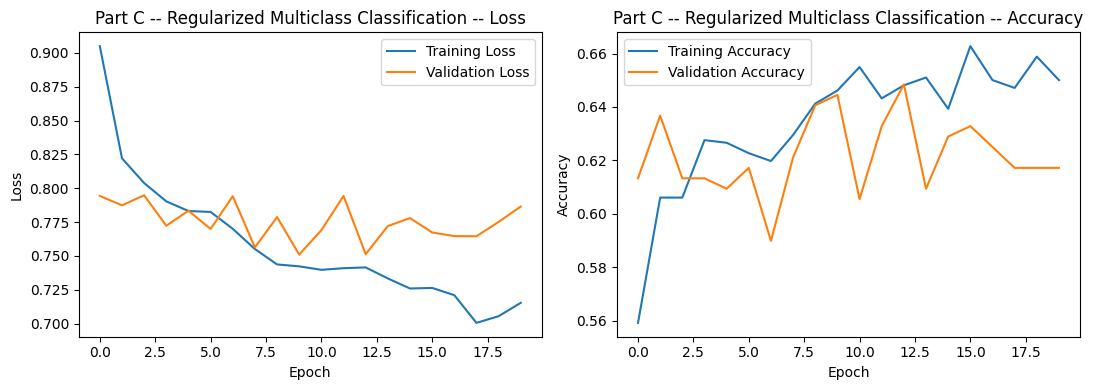

In [41]:
# Retrain the model with Dropout and Early Stopping
print("Training regularized model with Dropout and Early Stopping...")
history_regularized = regularized_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

# Plot the training versus validation loss curve
plot_history(history_regularized, "Part C -- Regularized Multiclass Classification", show_accuracy=True)

### Comparison to Original Lab 1 Curve

*   **Original Lab 1 Curve (from Part A):** The plot for Lab 1 showed a clear divergence, with validation loss plateauing and then increasing after around 20-30 epochs, while training loss continued to decrease. This indicated overfitting.

*   **New Regularized Model Curve (from Part C):** The curve for "Part C -- Regularized Multiclass Classification" should ideally show:
    *   **Shrunk Gap:** The gap between training and validation loss should be smaller, suggesting better generalization.
    *   **Validation Loss Behavior:** Validation loss should either stabilize or continue to decrease for a longer period, without a sharp increase. Early Stopping should prevent it from rising significantly by stopping training when improvement halts.

*   **Did overfitting reduce?** Analyze the new plot to determine if the gap between training and validation loss has shrunk, and if the validation loss behaves more stably or improves further into training compared to the original model. The Early Stopping callback specifically helps in preventing the validation loss from rising by stopping training at an optimal point.

Part C -- Regularized Model Test Accuracy: 0.659
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


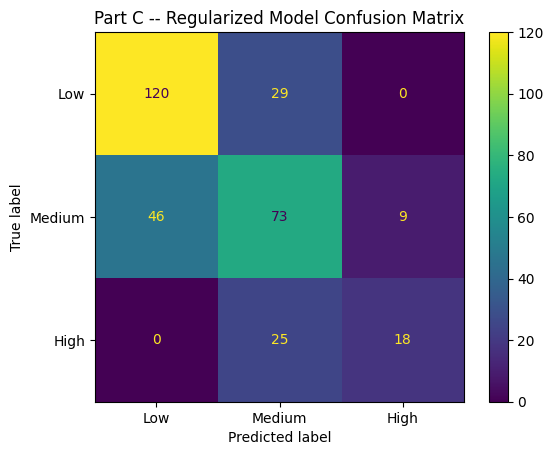

Original Lab 1 Test Accuracy: 0.656
Tuned Model (Part B) Test Accuracy: 0.697


In [42]:
# Report final test accuracy and confusion matrix
loss_regularized, acc_regularized = regularized_model.evaluate(X3_test_scaled, y3_test, verbose=0)

print(f"Part C -- Regularized Model Test Accuracy: {acc_regularized:.3f}")

# Generate confusion matrix
regularized_probs = regularized_model.predict(X3_test_scaled)
regularized_preds = np.argmax(regularized_probs, axis=1)

cm_regularized = confusion_matrix(y3_test, regularized_preds)
ConfusionMatrixDisplay(cm_regularized, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Regularized Model Confusion Matrix")
plt.show()

print(f"Original Lab 1 Test Accuracy: {acc_multi:.3f}")
print(f"Tuned Model (Part B) Test Accuracy: {acc_tuned:.3f}")

## Part D: Reflection

Answer in 4 to 6 sentences total:

1.  **Why is it important that your test set was touched only once, at the very end?**

    *Your answer:*  It's crucial that the test set is used only once, at the very end, to provide an unbiased evaluation of the model's performance. The test set acts as a proxy for the unseen real-world data. If it was used during model development or hyperparameter tuning, the model would learn from it, leading to an overly optimistic and unrealistic assessment of its capabilities.

2.  **What would have gone wrong if you had used your test set to pick the best hyperparameter configuration instead of a validation split?**

    *Your answer:* If the test set were used for hyperparameter tuning, the model's hyperparameters would be optimized specifically for that particular test set. This process would introduce data leakage from the test set into the model training and tuning. The performance metrics reported on the 'tuned' test set would be inflated and making the model seem more robust than it truly is.

3.  **Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What evidence from your new loss curve supports your answer?**

    *Your answer:* Yes, Early Stopping did meaningfully reduce the overfitting. Early stopping Restoring model weights from the end of the best epoch: 10.. indicates that the training process was halted when the validation loss stopped improving.

4.  **If you had unlimited time and compute, what would you try next to improve this model further?**

    *Your answer:* With unlimited resources, I would explore a broader range of hyperparameter values and potentially more complex architectures, such as adding more hidden layers or trying different activation functions. I would consider exploring ensemble methods. Extensive feature engineering and selection could also yield significant improvements.
